Import Important Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Load the Dataset

In [13]:
# Step 2: Load the Dataset
df = pd.read_csv('D:\excel\marketing_campaign.csv', sep='\t')

# Drop columns that don't help clustering
df = df.drop(['Z_CostContact', 'Z_Revenue', 'Dt_Customer'], axis=1)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())



Shape: (2240, 26)

First 5 rows:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

   Recency  MntWines  MntFruits  ...  NumCatalogPurchases  NumStorePurchases  \
0       58       635         88  ...                   10                  4   
1       38        11          1  ...                    1                  2   
2       26       426         49  ...                    2                 10   
3       26        11          4  ...                    0                  4   
4       94       173         43  ...                    3                  6   

   NumWebVisitsMo

Check Missing Values


In [14]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

Data types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Recency                  int64
MntWines                 int64
Mnt

Handle Missing Values

In [15]:
# Check how many missing values in Income
print("Missing Income values:", df['Income'].isnull().sum())

# Fill missing Income with the median
df['Income'] = df['Income'].fillna(df['Income'].median())

# Verify no missing values remain
print("Missing values after fix:", df.isnull().sum().sum())

Missing Income values: 24
Missing values after fix: 0


Drop Useless Columns

In [16]:
# Drop columns that don't help clustering
df = df.drop(['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'], axis=1, errors='ignore')

print("Shape after dropping:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

Shape after dropping: (2240, 25)

Remaining columns:
['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


Quick Data Check

In [17]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (2240, 25)

First 5 rows:
   Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  Recency  \
0        1957  Graduation         Single  58138.0        0         0       58   
1        1954  Graduation         Single  46344.0        1         1       38   
2        1965  Graduation       Together  71613.0        0         0       26   
3        1984  Graduation       Together  26646.0        1         0       26   
4        1981         PhD        Married  58293.0        1         0       94   

   MntWines  MntFruits  MntMeatProducts  ...  NumCatalogPurchases  \
0       635         88              546  ...                   10   
1        11          1                6  ...                    1   
2       426         49              127  ...                    2   
3        11          4               20  ...                    0   
4       173         43              118  ...                    3   

   NumStorePurchases  NumWebVisitsMonth  AcceptedCmp3  AcceptedCm

 Keep Only Numeric Columns

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Number of numeric features:", len(numeric_cols))
print("\nNumeric columns:")
for i, col in enumerate(numeric_cols):
    print(f"{i+1}. {col}")

df_numeric = df[numeric_cols].copy()
print("\nNumeric shape:", df_numeric.shape)

Number of numeric features: 23

Numeric columns:
1. Year_Birth
2. Income
3. Kidhome
4. Teenhome
5. Recency
6. MntWines
7. MntFruits
8. MntMeatProducts
9. MntFishProducts
10. MntSweetProducts
11. MntGoldProds
12. NumDealsPurchases
13. NumWebPurchases
14. NumCatalogPurchases
15. NumStorePurchases
16. NumWebVisitsMonth
17. AcceptedCmp3
18. AcceptedCmp4
19. AcceptedCmp5
20. AcceptedCmp1
21. AcceptedCmp2
22. Complain
23. Response

Numeric shape: (2240, 23)


Remove Outliers

In [19]:
def remove_outliers(data, columns):
    mask = pd.Series(True, index=data.index)
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = mask & (data[col] >= lower) & (data[col] <= upper)
    return data[mask], mask

df_cleaned, mask = remove_outliers(df_numeric, numeric_cols)

print("Before:", df_numeric.shape[0])
print("After:", df_cleaned.shape[0])
print("Removed:", df_numeric.shape[0] - df_cleaned.shape[0], "rows")

Before: 2240
After: 1208
Removed: 1032 rows


Scale the Features

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

scaled_df = pd.DataFrame(scaled_data, columns=df_cleaned.columns)

print("Before scaling:")
print(df_cleaned[['Income', 'MntWines', 'Recency']].describe().loc[['mean', 'std']].round(2))

print("\nAfter scaling:")
print(scaled_df[['Income', 'MntWines', 'Recency']].describe().loc[['mean', 'std']].round(2))

Before scaling:
        Income  MntWines  Recency
mean  42074.11    143.60    50.79
std   16136.53    207.45    28.75

After scaling:
      Income  MntWines  Recency
mean     0.0      -0.0     -0.0
std      1.0       1.0      1.0


Apply PCA to Reduce Dimensions

In [21]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(scaled_data)

cumulative_var = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumulative_var >= 0.95) + 1

print("Original features:", scaled_data.shape[1])
print("Components needed for 95% variance:", n_components)
print("Variance captured:", round(cumulative_var[n_components-1]*100, 2), "%")

Original features: 23
Components needed for 95% variance: 12
Variance captured: 95.61 %


Plot PCA Explained Variance

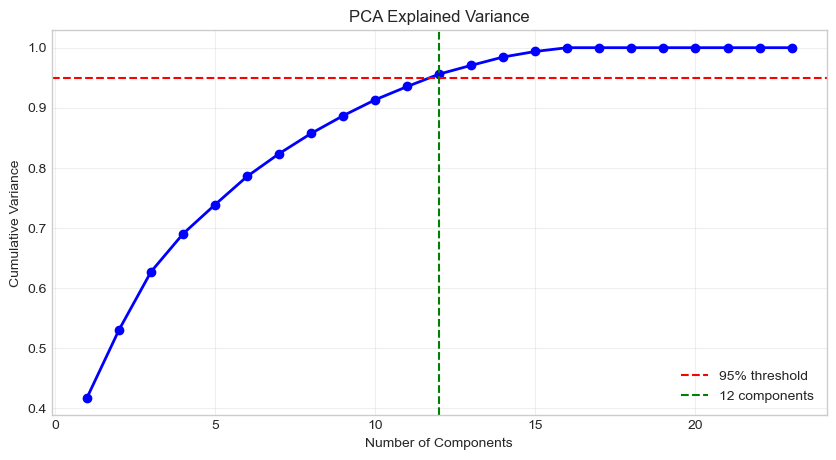

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, 'bo-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Apply Final PCA

In [23]:
pca_final = PCA(n_components=n_components)
pca_data = pca_final.fit_transform(scaled_data)

print("Original shape:", scaled_data.shape)
print("PCA shape:", pca_data.shape)
print("Data compressed from", scaled_data.shape[1], "features to", pca_data.shape[1], "components")

Original shape: (1208, 23)
PCA shape: (1208, 12)
Data compressed from 23 features to 12 components


Find Optimal K with Elbow Method

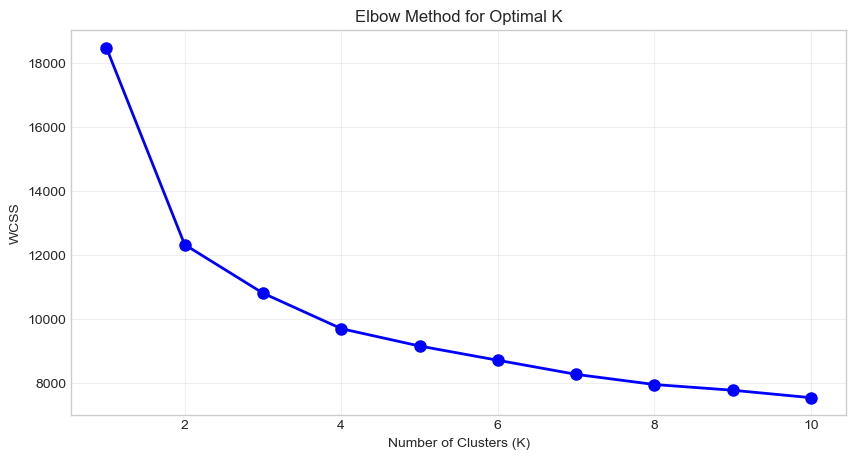

K = 1  WCSS = 18480.32
K = 2  WCSS = 12326.67
K = 3  WCSS = 10811.05
K = 4  WCSS = 9702.1
K = 5  WCSS = 9159.71
K = 6  WCSS = 8714.46
K = 7  WCSS = 8273.75
K = 8  WCSS = 7956.44
K = 9  WCSS = 7777.87
K = 10  WCSS = 7545.22


In [24]:
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_data)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.show()

for k, w in zip(k_range, wcss):
    print("K =", k, " WCSS =", round(w, 2))

Confirm K with Silhouette Score

K = 2  Silhouette Score = 0.3716
K = 3  Silhouette Score = 0.2602
K = 4  Silhouette Score = 0.178
K = 5  Silhouette Score = 0.1819
K = 6  Silhouette Score = 0.174
K = 7  Silhouette Score = 0.1723
K = 8  Silhouette Score = 0.1403
K = 9  Silhouette Score = 0.1393
K = 10  Silhouette Score = 0.1419

Best K by silhouette: 2


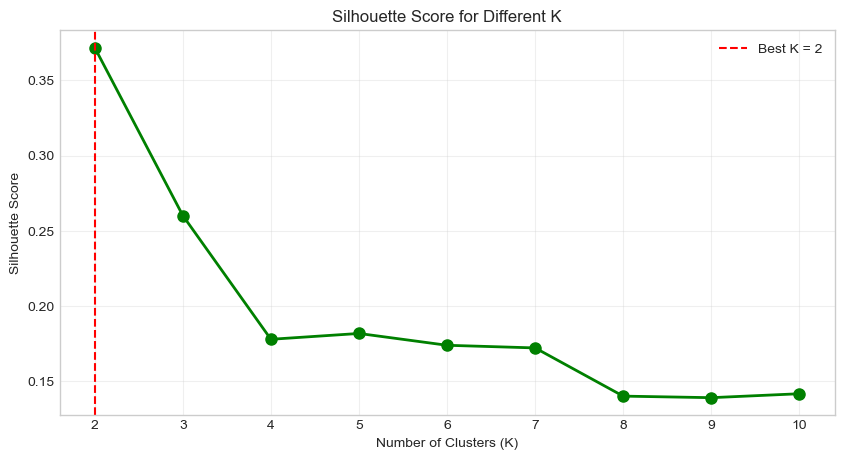

In [25]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    sil_scores.append(score)
    print("K =", k, " Silhouette Score =", round(score, 4))

best_k = k_range_sil[np.argmax(sil_scores)]
print("\nBest K by silhouette:", best_k)

plt.figure(figsize=(10, 5))
plt.plot(k_range_sil, sil_scores, 'go-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', label='Best K = ' + str(best_k))
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Run Final K-Means

In [26]:
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pca_data)

print("Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Cluster distribution:
0    372
1    159
2    240
3    437
Name: count, dtype: int64


Attach Clusters Back to Original Data

In [27]:
full_labels = pd.Series(index=df.index, dtype='float64')
full_labels[mask] = cluster_labels
full_labels = full_labels.fillna(-1).astype(int)

df['Cluster'] = full_labels

print("Cluster counts:")
print(df['Cluster'].value_counts().sort_index())

print("\nOutliers marked as -1:", len(df[df['Cluster'] == -1]))

Cluster counts:
Cluster
-1    1032
 0     372
 1     159
 2     240
 3     437
Name: count, dtype: int64

Outliers marked as -1: 1032


Visualize Clusters

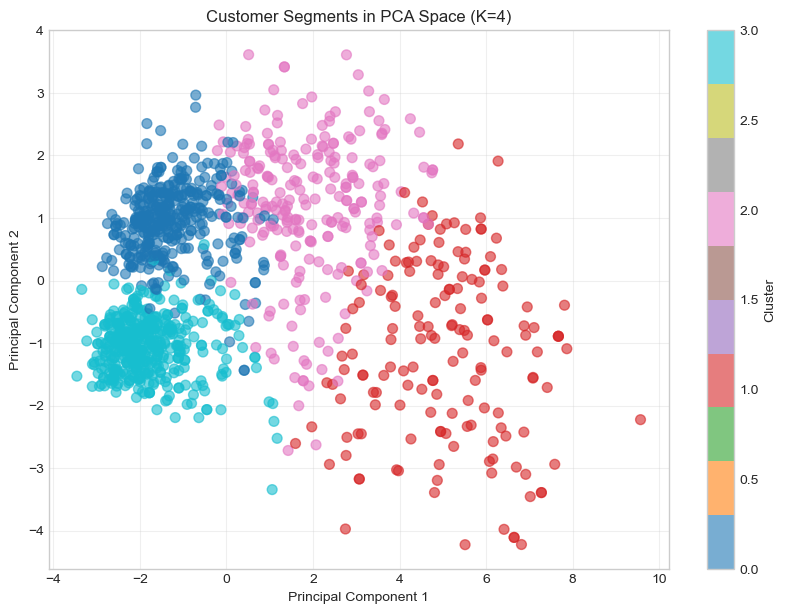

In [28]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=cluster_labels, 
                     cmap='tab10', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments in PCA Space (K=4)')
plt.grid(True, alpha=0.3)
plt.show()

Reverse Centroids to Original Scale

In [29]:
centroids_pca = kmeans.cluster_centers_

centroids_original = pca_final.inverse_transform(centroids_pca)
centroids_unscaled = scaler.inverse_transform(centroids_original)

centroid_df = pd.DataFrame(centroids_unscaled, columns=df_cleaned.columns)

print("Centroids in original units:")
print(centroid_df.round(2))

Centroids in original units:
   Year_Birth    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0     1963.78  40363.20     0.73      0.97    51.28     41.57       3.02   
1     1967.32  65955.42     0.12      0.58    51.79    453.08      36.13   
2     1964.19  52805.99     0.26      0.96    47.68    314.45      10.95   
3     1978.27  28947.52     0.85      0.01    51.72     24.03       5.45   

   MntMeatProducts  MntFishProducts  MntSweetProducts  ...  \
0            12.22             3.83              2.89  ...   
1           234.46            54.70             36.97  ...   
2            88.20            15.49             10.63  ...   
3            24.09             8.07              5.59  ...   

   NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  AcceptedCmp3  \
0                 0.51               3.28               5.72           0.0   
1                 4.23               8.72               3.90           0.0   
2                 2.01               6.70    

Create Cluster Profiles

In [30]:
profiles = df[df['Cluster'] != -1].groupby('Cluster')[numeric_cols].mean()

print("Cluster Profiles (Average Values):")
print(profiles.round(2))

Cluster Profiles (Average Values):
         Year_Birth    Income  Kidhome  Teenhome  Recency  MntWines  \
Cluster                                                               
0           1963.81  40188.86     0.72      0.97    51.27     42.78   
1           1967.32  65360.47     0.13      0.59    51.85    459.38   
2           1964.18  53406.18     0.25      0.95    47.64    306.83   
3           1978.25  28982.78     0.86      0.01    51.73     24.89   

         MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  ...  \
Cluster                                                                 ...   
0             2.93            16.26             3.66              2.93  ...   
1            36.00           235.23            54.96             36.94  ...   
2            11.05            86.30            15.34             10.60  ...   
3             5.51            21.41             8.20              5.58  ...   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMo

Compare Against

Compare Against Overall Average

In [31]:
overall = df[numeric_cols].mean()
deviation = (profiles - overall) / overall * 100

print("Deviation from overall average (%):")
print(deviation.round(1))

Deviation from overall average (%):
         Year_Birth  Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
Cluster                                                                        
0              -0.3   -23.1     62.8      91.7      4.4     -85.9      -88.8   
1              -0.1    25.1    -71.7      16.8      5.6      51.1       36.9   
2              -0.2     2.2    -42.8      86.8     -3.0       1.0      -58.0   
3               0.5   -44.5     92.7     -98.2      5.3     -91.8      -79.1   

         MntMeatProducts  MntFishProducts  MntSweetProducts  ...  \
Cluster                                                      ...   
0                  -90.3            -90.2             -89.2  ...   
1                   40.9             46.5              36.5  ...   
2                  -48.3            -59.1             -60.8  ...   
3                  -87.2            -78.1             -79.4  ...   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  \
Clus

Save Results

In [32]:
df.to_csv('customer_segments.csv', index=False)
profiles.to_csv('cluster_profiles.csv')

print("Files saved:")
print("- customer_segments.csv")
print("- cluster_profiles.csv")

Files saved:
- customer_segments.csv
- cluster_profiles.csv


Business Persona Summary

In [33]:
for c in range(4):
    print("\n" + "="*50)
    print("CLUSTER", c)
    print("="*50)
    print("Customers:", len(df[df['Cluster']==c]))
    print("\nTop 5 high features:")
    top = deviation.loc[c].nlargest(5)
    for feat, val in top.items():
        print("  High", feat, ":", round(val), "% above average")
    print("\nTop 3 low features:")
    bottom = deviation.loc[c].nsmallest(3)
    for feat, val in bottom.items():
        print("  Low", feat, ":", round(abs(val)), "% below average")


CLUSTER 0
Customers: 372

Top 5 high features:
  High Teenhome : 92 % above average
  High Kidhome : 63 % above average
  High NumWebVisitsMonth : 7 % above average
  High Recency : 4 % above average
  High Year_Birth : 0 % above average

Top 3 low features:
  Low AcceptedCmp3 : 100 % below average
  Low AcceptedCmp4 : 100 % below average
  Low AcceptedCmp5 : 100 % below average

CLUSTER 1
Customers: 159

Top 5 high features:
  High NumCatalogPurchases : 57 % above average
  High NumStorePurchases : 53 % above average
  High MntWines : 51 % above average
  High MntFishProducts : 46 % above average
  High MntMeatProducts : 41 % above average

Top 3 low features:
  Low AcceptedCmp3 : 100 % below average
  Low AcceptedCmp4 : 100 % below average
  Low AcceptedCmp5 : 100 % below average

CLUSTER 2
Customers: 240

Top 5 high features:
  High Teenhome : 87 % above average
  High NumDealsPurchases : 42 % above average
  High NumWebPurchases : 33 % above average
  High NumStorePurchases : 15 %

Clean Up The Persona Output

In [34]:
# Exclude campaign columns that are all zeros
skip_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
             'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Response']

clean_deviation = deviation.drop(columns=[c for c in skip_cols if c in deviation.columns])

for c in range(4):
    print("\n" + "="*50)
    print("CLUSTER", c)
    print("="*50)
    print("Customers:", len(df[df['Cluster']==c]))
    
    print("\nTop 5 high features:")
    top = clean_deviation.loc[c].nlargest(5)
    for feat, val in top.items():
        print("  ", feat, ":", round(val), "% above average")
    
    print("\nTop 3 low features:")
    bottom = clean_deviation.loc[c].nsmallest(3)
    for feat, val in bottom.items():
        print("  ", feat, ":", round(abs(val)), "% below average")


CLUSTER 0
Customers: 372

Top 5 high features:
   Teenhome : 92 % above average
   Kidhome : 63 % above average
   NumWebVisitsMonth : 7 % above average
   Recency : 4 % above average
   Year_Birth : 0 % above average

Top 3 low features:
   MntMeatProducts : 90 % below average
   MntFishProducts : 90 % below average
   MntSweetProducts : 89 % below average

CLUSTER 1
Customers: 159

Top 5 high features:
   NumCatalogPurchases : 57 % above average
   NumStorePurchases : 53 % above average
   MntWines : 51 % above average
   MntFishProducts : 46 % above average
   MntMeatProducts : 41 % above average

Top 3 low features:
   Kidhome : 72 % below average
   NumWebVisitsMonth : 27 % below average
   NumDealsPurchases : 5 % below average

CLUSTER 2
Customers: 240

Top 5 high features:
   Teenhome : 87 % above average
   NumDealsPurchases : 42 % above average
   NumWebPurchases : 33 % above average
   NumStorePurchases : 15 % above average
   NumWebVisitsMonth : 7 % above average

Top 3 low

Write Business Personas

In [35]:
personas = {
    0: {
        'name': 'Family Shoppers',
        'desc': 'Customers with kids and teens at home. Low spending on premium items. Browse website often but buy less.'
    },
    1: {
        'name': 'Premium Buyers',
        'desc': 'High income, no kids. Big spenders on wine, meat, fish. Shop via catalog and store. Most valuable customers.'
    },
    2: {
        'name': 'Deal Hunters',
        'desc': 'Families with teens. Love discounts and deals. Shop via web and store. Moderate spending.'
    },
    3: {
        'name': 'Budget Families',
        'desc': 'Young families with small kids. Very low spending on all products. Visit website a lot but rarely buy.'
    }
}

for c in range(4):
    print("\n" + "="*60)
    print("PERSONA:", personas[c]['name'])
    print("="*60)
    print("Cluster:", c)
    print("Size:", len(df[df['Cluster']==c]), "customers")
    print("\nDescription:")
    print(" ", personas[c]['desc'])


PERSONA: Family Shoppers
Cluster: 0
Size: 372 customers

Description:
  Customers with kids and teens at home. Low spending on premium items. Browse website often but buy less.

PERSONA: Premium Buyers
Cluster: 1
Size: 159 customers

Description:
  High income, no kids. Big spenders on wine, meat, fish. Shop via catalog and store. Most valuable customers.

PERSONA: Deal Hunters
Cluster: 2
Size: 240 customers

Description:
  Families with teens. Love discounts and deals. Shop via web and store. Moderate spending.

PERSONA: Budget Families
Cluster: 3
Size: 437 customers

Description:
  Young families with small kids. Very low spending on all products. Visit website a lot but rarely buy.


Marketing Recommendations

In [36]:
actions = {
    0: "Send family bundle offers. Promote kid-friendly products. Use email campaigns.",
    1: "VIP treatment. Exclusive wine and gourmet offers. Personal shopping assistant.",
    2: "Discount alerts. Loyalty points promotions. Flash sale notifications.",
    3: "Budget-friendly starter packs. Free samples to build habit. Re-engagement emails."
}

print("MARKETING ACTION PLAN")
print("="*60)
for c in range(4):
    print("\n" + personas[c]['name'])
    print("-"*40)
    print("Action:", actions[c])

MARKETING ACTION PLAN

Family Shoppers
----------------------------------------
Action: Send family bundle offers. Promote kid-friendly products. Use email campaigns.

Premium Buyers
----------------------------------------
Action: VIP treatment. Exclusive wine and gourmet offers. Personal shopping assistant.

Deal Hunters
----------------------------------------
Action: Discount alerts. Loyalty points promotions. Flash sale notifications.

Budget Families
----------------------------------------
Action: Budget-friendly starter packs. Free samples to build habit. Re-engagement emails.
